# Analiza napływu powiadomień

Firma **DataPulse Analytics**, zajmująca się analizą zachowań użytkowników mobilnych, bada natężenie powiadomień w aplikacjach. W ciągu godziny różne aplikacje generują różną liczbę powiadomień, a ich aktywność zmienia się w czasie – występują momenty szczytowe oraz okresy o niższym natężeniu.  

Celem naszego projektu jest **oszacowanie łącznej liczby powiadomień**, które grupa użytkowników w pewnej firmie otrzymuje w ciągu godziny, na podstawie danych o 60 aplikacjach i ich charakterystyce czasowej.

---

## Dane i model matematyczny

- Liczba aplikacji: 60  
- Średnia liczba powiadomień w ciągu godziny dla każdej aplikacji: $x_i \in [50, 500]$  
- Moment największego natężenia powiadomień dla aplikacji $i$: $c_i \in [0,1]$  

Funkcja opisująca natężenie powiadomień w czasie $t \in [0,1]$ jest dana wzorem:  

$$
f(x,t) = \sum_{i=1}^{60} x_i \cdot \exp\Big(-50 \cdot (t-c_i)^2\Big)
$$

Całka tej funkcji po czasie daje **łączną liczbę powiadomień w ciągu godziny**:

$$
\text{Łączna liczba powiadomień} = \int_0^1 f(x,t) \, dt
$$

---

## Nasze zadanie

W tym projekcie **zaimplementujemy numeryczne metody całkowania**, aby oszacować całkowitą liczbę powiadomień:

1. Zaimplementujemy wybraną metodę całkowania: prostokątów, trapezów lub Simpsona.  
2. Zastosujemy ją do funkcji $f(x,t)$ z danymi 60 aplikacji.  
3. Porównamy wyniki dla różnych metod i liczby podprzedziałów.


## Krok 1 - importujemy biblioteki

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Krok 2: Generowanie danych wejściowych

Dla każdej z 60 aplikacji generujemy dwa parametry:

- $x_i$ – średnią liczbę powiadomień generowanych przez aplikację w ciągu godziny  
- $c_i$ – moment największego natężenia powiadomień w trakcie godziny  

Zakładamy, że:
- liczba powiadomień $x_i$ mieści się w przedziale $[50, 500]$,
- moment szczytu $c_i$ jest losowy i należy do przedziału $[0,1]$.

Wartości te traktujemy jako dane empiryczne pochodzące z analizy zachowania użytkowników.

In [16]:
np.random.seed(359502)  # Tu podaj swoj numer indeksu

n_apps = 60

# średnia liczba powiadomień w ciągu godziny
x = np.random.uniform(50, 500, size=n_apps)

# moment największego natężenia powiadomień
c = np.random.uniform(0, 1, size=n_apps)

## Krok 3: Definicja funkcji natężenia powiadomień

Definiujemy funkcję $f(x,t)$ opisującą łączne natężenie powiadomień w czasie $t \in [0,1]$.

Każda aplikacja generuje powiadomienia zgodnie z funkcją o maksimum w punkcie $c_i$.
Zakładamy, że kształt natężenia można modelować funkcją Gaussa (czyli zasadniczo $e^{-x^2}$), a parametr $x_i$
skaluje jej amplitudę.

Całkowite natężenie powiadomień w chwili $t$ jest sumą wkładów wszystkich aplikacji:
$$
f(x,t) = \sum_{i=1}^{60} x_i \cdot \exp\bigl(-50 (t - c_i)^2\bigr).
$$

Funkcja ta będzie całkowana numerycznie w kolejnych krokach.

In [17]:
def f(t, x, c):
    return np.sum(x * np.exp(-50 * (t - c)**2))

## Krok 4: Wizualizacja funkcji $f(x,t)$

Zanim przejdziemy do całkowania numerycznego, sprawdzimy, jak zachowuje się funkcja
natężenia powiadomień w czasie.

Narysujemy wykres funkcji $f(x,t)$ dla $t \in [0,1]$, korzystając z wcześniej
wylosowanych danych. Pozwoli to:
- zobaczyć momenty największego natężenia powiadomień,
- ocenić regularność (lub jej brak) funkcji,
- zrozumieć, dlaczego całkowanie analityczne nie jest w tym przypadku praktyczne.

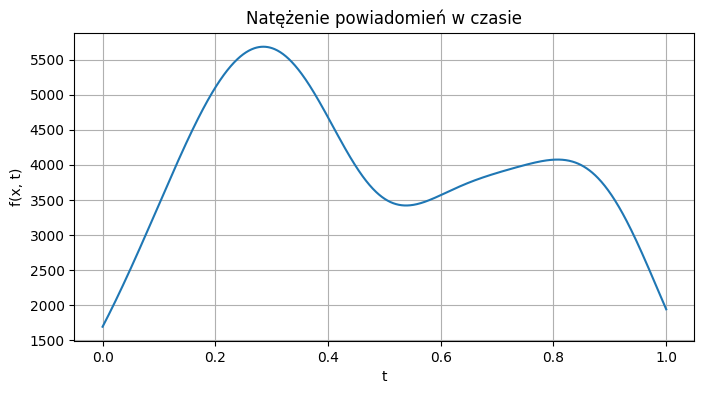

In [18]:

t_vals = np.linspace(0, 1, 1000)
f_vals = np.array([f(t, x, c) for t in t_vals])

plt.figure(figsize=(8, 4))
plt.plot(t_vals, f_vals)
plt.xlabel("t")
plt.ylabel("f(x, t)")
plt.title("Natężenie powiadomień w czasie")
plt.grid(True)
plt.show()

## Krok 5: Całkowanie numeryczne – suma Riemanna

Pierwszą metodą całkowania numerycznego, którą zaimplementujemy, będzie **suma Riemanna**.

Dzielimy przedział $[0,1]$ na $N$ równych podprzedziałów o długości
$$
\Delta t = \frac{1}{N}.
$$

Przyjmując wartości funkcji w lewych końcach podprzedziałów, przybliżenie całki
ma postać:
$$
\int_0^1 f(x,t)\,dt \;\approx\; \sum_{k=0}^{N-1} f(x, t_k)\,\Delta t,
\qquad
t_k = k\,\Delta t.
$$

W kolejnej komórce zaimplementujemy tę metodę i użyjemy jej do oszacowania
łącznej liczby powiadomień w ciągu godziny.

---

### Specyfikacja funkcji

Należy zaimplementować funkcję realizującą powyższy algorytm.

**Nazwa funkcji:**  
`riemann_sum`

**Argumenty:**
- `f` – funkcja jednej zmiennej czasu `t`, zwracająca wartość $f(x,t)$,
- `x` – wektor parametrów $x_i$,
- `c` – wektor parametrów $c_i$,
- `N` – liczba podprzedziałów (liczba prostokątów).

**Zwracana wartość:**
- przybliżenie całki $\int_0^1 f(x,t)\,dt$ jako liczba typu `float`.

Funkcja nie powinna korzystać z gotowych narzędzi do całkowania numerycznego.

In [19]:
def riemann_sum(f, x, c, N):
    dt = 1.0 / N
    t_vals = np.linspace(0, 1 - dt, N)
    return np.sum([f(t, x, c) for t in t_vals]) * dt

## Krok 6: Testowanie implementacji

Sprawdzimy działanie zaimplementowanej sumy Riemanna, obliczając przybliżenie
całki dla różnych wartości liczby podprzedziałów $N$.

Celem testu jest:
- sprawdzenie stabilności implementacji,
- obserwacja wpływu liczby prostokątów na wynik,
- wstępna analiza zbieżności metody.

In [20]:
N_values = [10, 50, 100, 500, 1000, 5000]

for N in N_values:
    approx = riemann_sum(f, x, c, N)
    print(f"N = {N:5d}, przybliżenie całki = {approx:.4f}")

N =    10, przybliżenie całki = 3922.1706
N =    50, przybliżenie całki = 3959.7104
N =   100, przybliżenie całki = 3961.8029
N =   500, przybliżenie całki = 3963.0682
N =  1000, przybliżenie całki = 3963.2009
N =  5000, przybliżenie całki = 3963.3029


## Krok 7: Wizualizacja sumy Riemanna

Aby lepiej zrozumieć ideę całkowania numerycznego, narysujemy przybliżenie całki
za pomocą **prostokątów sumy Riemanna**.

Na wykresie przedstawimy:
- wykres funkcji $f(x,t)$,
- prostokąty odpowiadające lewym punktom podprzedziałów.

Taka wizualizacja pozwala bezpośrednio zobaczyć, w jaki sposób suma Riemanna
aproksymuje pole pod wykresem.

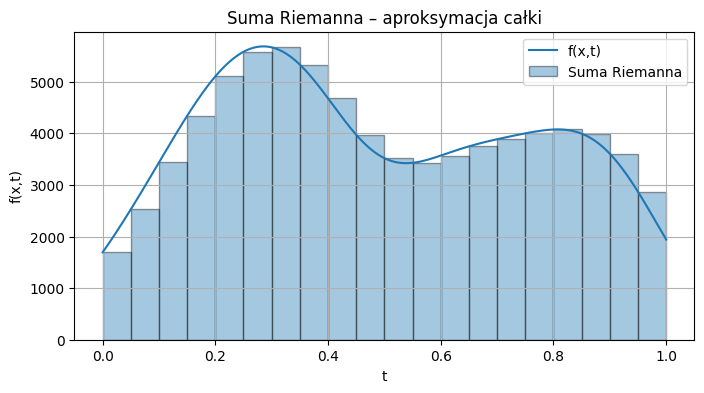

In [21]:
N = 20  # niewielka liczba podprzedziałów, żeby prostokąty były widoczne
dt = 1.0 / N
t_rect = np.linspace(0, 1 - dt, N)
f_rect = np.array([f(t, x, c) for t in t_rect])

# wykres funkcji
t_vals = np.linspace(0, 1, 1000)
f_vals = np.array([f(t, x, c) for t in t_vals])

plt.figure(figsize=(8, 4))
plt.plot(t_vals, f_vals, label="f(x,t)")

# prostokąty sumy Riemanna
plt.bar(t_rect, f_rect, width=dt, align="edge", alpha=0.4, edgecolor="black",
        label="Suma Riemanna")

plt.xlabel("t")
plt.ylabel("f(x,t)")
plt.title("Suma Riemanna – aproksymacja całki")
plt.legend()
plt.grid(True)
plt.show()

## Krok 8: Całkowanie numeryczne – metoda trapezów

Drugą metodą całkowania numerycznego, którą zaimplementujemy, będzie
**metoda trapezów**.

Dzielimy przedział $[0,1]$ na $N$ równych podprzedziałów o długości
$$
\Delta t = \frac{1}{N}.
$$

Na każdym podprzedziale $[t_k, t_{k+1}]$ funkcję przybliżamy odcinkiem prostym,
co prowadzi do wzoru:
$$
\int_0^1 f(x,t)\,dt \;\approx\;
\sum_{k=0}^{N-1} \frac{f(x,t_k) + f(x,t_{k+1})}{2}\,\Delta t,
\qquad
t_k = k\,\Delta t.
$$

Metoda trapezów jest zazwyczaj dokładniejsza od sumy Riemanna,
ponieważ uwzględnia wartości funkcji na obu końcach podprzedziału.

### Specyfikacja funkcji

**Nazwa funkcji:**  
`trapezoidal_rule`

**Argumenty:**
- `f` – funkcja jednej zmiennej czasu `t`, zwracająca wartość $f(x,t)$,
- `x` – wektor parametrów $x_i$,
- `c` – wektor parametrów $c_i$,
- `N` – liczba podprzedziałów.

**Zwracana wartość:**
- przybliżenie całki $\int_0^1 f(x,t)\,dt$ jako liczba typu `float`.

Funkcja nie powinna korzystać z gotowych procedur całkowania numerycznego.

In [22]:
def trapezoidal_rule(f, x, c, N):
    dt = 1.0 / N
    t_vals = np.linspace(0, 1, N + 1)
    f_vals = np.array([f(t, x, c) for t in t_vals])
    return np.sum((f_vals[:-1] + f_vals[1:]) * 0.5 * dt)

## Krok 9: Testowanie metody trapezów

Sprawdzimy działanie metody trapezów, obliczając przybliżenie całki
dla różnych wartości liczby podprzedziałów $N$.

Następnie porównamy wyniki z otrzymanymi wcześniej przy użyciu sumy Riemanna.
Pozwoli to ocenić dokładność obu metod oraz ich zachowanie wraz ze wzrostem $N$.

In [23]:
N_values = [10, 50, 100, 500, 1000, 5000]

print(f"{'N':>6} | {'Riemann':>15} | {'Trapezy':>15}")
print("-" * 42)

for N in N_values:
    riemann_val = riemann_sum(f, x, c, N)
    trapez_val = trapezoidal_rule(f, x, c, N)
    print(f"{N:6d} | {riemann_val:15.4f} | {trapez_val:15.4f}")

     N |         Riemann |         Trapezy
------------------------------------------
    10 |       3922.1706 |       3934.5850
    50 |       3959.7104 |       3962.1933
   100 |       3961.8029 |       3963.0443
   500 |       3963.0682 |       3963.3165
  1000 |       3963.2009 |       3963.3250
  5000 |       3963.3029 |       3963.3278


## Krok 10: Wizualizacja metody trapezów

Aby zobaczyć, jak metoda trapezów aproksymuje całkę, rysujemy:

- wykres funkcji $f(x,t)$,
- trapezy odpowiadające poszczególnym podprzedziałom.

Taka wizualizacja pozwala:

- zrozumieć, dlaczego metoda jest dokładniejsza od sumy Riemanna,
- zobaczyć geometrycznie przybliżanie pola pod krzywą.

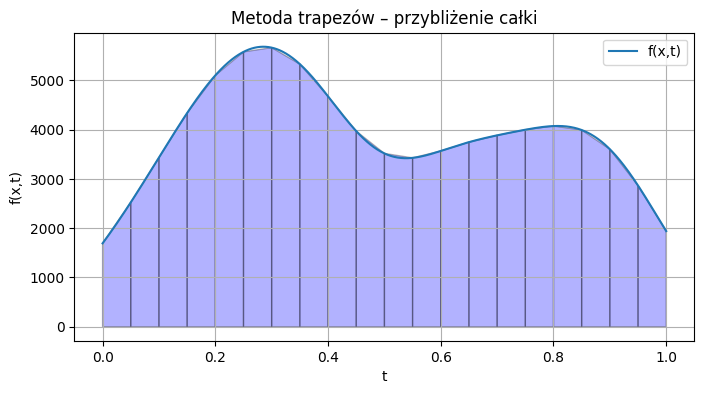

In [24]:
N = 20  # liczba podprzedziałów
dt = 1.0 / N
t_trap = np.linspace(0, 1, N + 1)
f_trap = np.array([f(t, x, c) for t in t_trap])

plt.figure(figsize=(8, 4))

# wykres funkcji
t_vals = np.linspace(0, 1, 1000)
f_vals = np.array([f(t, x, c) for t in t_vals])
plt.plot(t_vals, f_vals, label="f(x,t)")

# rysowanie trapezów
for k in range(N):
    xs = [t_trap[k], t_trap[k], t_trap[k+1], t_trap[k+1]]
    ys = [0, f_trap[k], f_trap[k+1], 0]
    plt.fill(xs, ys, 'b', alpha=0.3, edgecolor='black')

plt.xlabel("t")
plt.ylabel("f(x,t)")
plt.title("Metoda trapezów – przybliżenie całki")
plt.grid(True)
plt.legend(["f(x,t)"])
plt.show()

## Krok 11: Całkowanie numeryczne – metoda Simpsona

Kolejną metodą, którą zaimplementujemy, jest **metoda Simpsona**.

Dzielimy przedział $[0,1]$ na $N$ równych podprzedziałów (liczba $N$ musi być parzysta)
o długości:
$$
\Delta t = \frac{1}{N}.
$$

Przybliżenie całki na podstawie parzystych podprzedziałów:
$$
\int_0^1 f(x,t)\,dt \;\approx\; \frac{\Delta t}{3} \Big[
f(x,t_0) + 4 \sum_{k=1,3,5...}^{N-1} f(x,t_k) + 2 \sum_{k=2,4,6...}^{N-2} f(x,t_k) + f(x,t_N) \Big]
$$

Metoda Simpsona jest zazwyczaj dokładniejsza niż suma Riemanna i metoda trapezów
dla tej samej liczby podprzedziałów.

### Specyfikacja funkcji

**Nazwa funkcji:**  
`simpson_rule`

**Argumenty:**
- `f` – funkcja jednej zmiennej czasu `t`, zwracająca wartość $f(x,t)$,
- `x` – wektor parametrów $x_i$,
- `c` – wektor parametrów $c_i$,
- `N` – liczba podprzedziałów (parzysta!).

**Zwracana wartość:**
- przybliżenie całki $\int_0^1 f(x,t)\,dt$ jako liczba typu `float`.

Funkcja nie powinna korzystać z gotowych procedur całkowania numerycznego.

In [25]:
def simpson_rule(f, x, c, N):
    if N % 2 == 1:
        raise ValueError("N musi być parzyste dla metody Simpsona")

    dt = 1.0 / N
    t_vals = np.linspace(0, 1, N + 1)
    f_vals = np.array([f(t, x, c) for t in t_vals])

    S = f_vals[0] + f_vals[-1]                  # krańce przedziału
    S += 4 * np.sum(f_vals[1:-1:2])            # suma wartości na nieparzystych indeksach
    S += 2 * np.sum(f_vals[2:-2:2])            # suma wartości na parzystych indeksach
    return S * dt / 3

## Krok 12: Porównanie sumy Riemanna, metody trapezów i Simpsona

W tym kroku porównamy wyniki wszystkich trzech metod dla różnych liczb podprzedziałów $N$.

Celem jest:

- obserwacja zbieżności wyników w zależności od $N$,
- porównanie dokładności metod,
- pokazanie, jak wybór metody wpływa na przybliżenie całki.

In [13]:
N_values = [10, 50, 100, 500, 1000, 5000]

print(f"{'N':>6} | {'Riemann':>15} | {'Trapezy':>15} | {'Simpson':>15}")
print("-" * 60)

for N in N_values:
    riemann_val = riemann_sum(f, x, c, N)
    trapez_val = trapezoidal_rule(f, x, c, N)
    simpson_val = simpson_rule(f, x, c, N if N % 2 == 0 else N+1)  # zapewniamy parzyste N
    print(f"{N:6d} | {riemann_val:15.4f} | {trapez_val:15.4f} | {simpson_val:15.4f}")

     N |         Riemann |         Trapezy |         Simpson
------------------------------------------------------------
    10 |       3734.7223 |       3746.3879 |       3771.1815
    50 |       3764.1733 |       3766.5064 |       3767.3259
   100 |       3765.9523 |       3767.1188 |       3767.3229
   500 |       3767.0813 |       3767.3146 |       3767.3227
  1000 |       3767.2041 |       3767.3207 |       3767.3227
  5000 |       3767.2993 |       3767.3227 |       3767.3227


## Krok 13: Wizualizacja metody Simpsona

Rysujemy przybliżenie całki metodą Simpsona dla niewielkiej liczby podprzedziałów.

Na wykresie zobaczymy:

- wykres funkcji $f(x,t)$,
- obszary aproksymowane metodą Simpsona

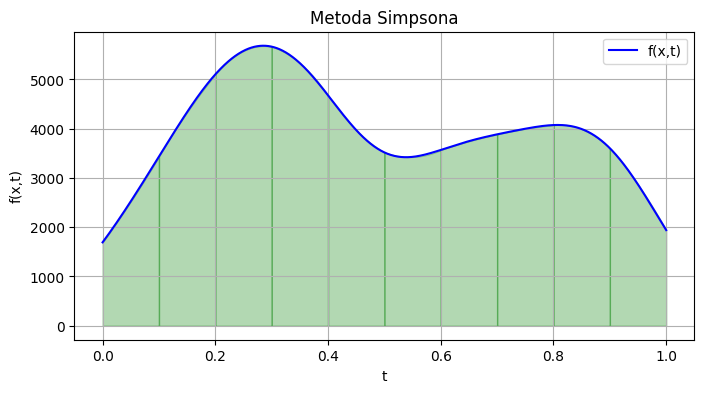

In [26]:
# Krok 13: poprawna wizualizacja metody Simpsona

from numpy.polynomial.polynomial import Polynomial

N = 20  # liczba podprzedziałów (parzysta)
t_simp = np.linspace(0, 1, N + 1)
f_simp = np.array([f(t, x, c) for t in t_simp])

t_vals = np.linspace(0, 1, 1000)
f_vals = np.array([f(t, x, c) for t in t_vals])

plt.figure(figsize=(8, 4))
plt.plot(t_vals, f_vals, 'b', label="f(x,t)")

# rysujemy parabolę dla każdej pary podprzedziałów
for k in range(0, N, 2):
    # trzy punkty: t_k, t_{k+1}, t_{k+2}
    t_sub = t_simp[k:k+3]
    f_sub = f_simp[k:k+3]

    # interpolacja parabolą (2. stopnia)
    coefs = np.polyfit(t_sub, f_sub, 2)  # a*t^2 + b*t + c
    t_plot = np.linspace(t_sub[0], t_sub[-1], 100)
    f_plot = np.polyval(coefs, t_plot)

    plt.fill_between(t_plot, f_plot, 0, color='g', alpha=0.3)

plt.xlabel("t")
plt.ylabel("f(x,t)")
plt.title("Metoda Simpsona")
plt.grid(True)
plt.legend()
plt.show()


## Krok 14: Zadanie końcowe

Firma **AppMetrics** zleciła nam obliczenie **łącznej liczby powiadomień**, które użytkownik otrzyma w ciągu godziny, na podstawie danych dla 60 aplikacji.

Twoim zadaniem jest:

1. Wykorzystać zaimplementowaną **metodę Simpsona** (lub trapezy / sumę Riemanna, jeśli chcesz porównać),
2. Obliczyć całkę $\int_0^1 f(x,t) \, dt$ z wcześniej wylosowanymi danymi `x` i `c`,
3. Podać wynik **z dokładnością do 4 miejsc po przecinku**.

In [27]:
N = 10000  # liczba podprzedziałów dla dokładnego wyniku
approx_simpson = simpson_rule(f, x, c, N)

print(f"Przybliżona liczba powiadomień (metoda Simpsona, N={N}): {approx_simpson:.6f}")

Przybliżona liczba powiadomień (metoda Simpsona, N=10000): 3963.327876


## Przetestuj zanim oddasz finalną wersję pracy!

Odpowiedzi dla poszczególnych indeksów.
1. 111111: $3888.7172$
2. 222222: $3773.5055$
3. 333333: $3904.5872$
4. 444444: $3664.9196$